In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sms
from datetime import datetime
plt.style.use('dark_background')

In [20]:
df = pd.read_csv(r"./monthly-beer-production-in-austr.csv")
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')
df.set_index('Month',inplace=True)
df.sort_index(inplace=True)
df.rename(columns={'Monthly beer production':'Prod'},inplace=True)
df.head()

,Prod
Month,
1956-01-01,93.2
1956-02-01,96.0
1956-03-01,95.2
1956-04-01,77.1
1956-05-01,70.9


<Axes: xlabel='Month'>

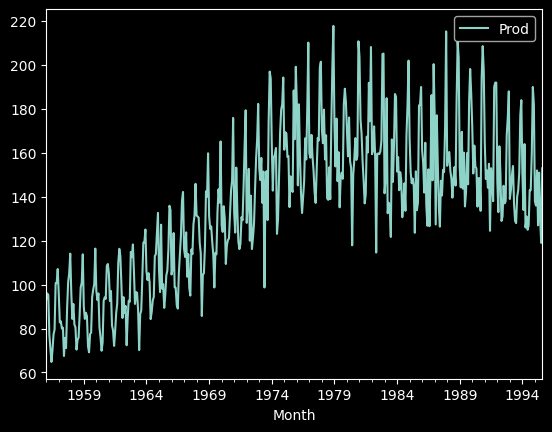

In [21]:
df.plot()

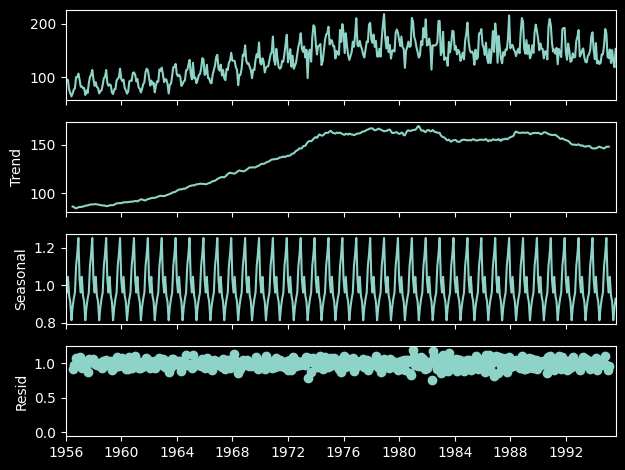

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose
res = seasonal_decompose(df, model='multiplicative')
res.plot()
plt.show()

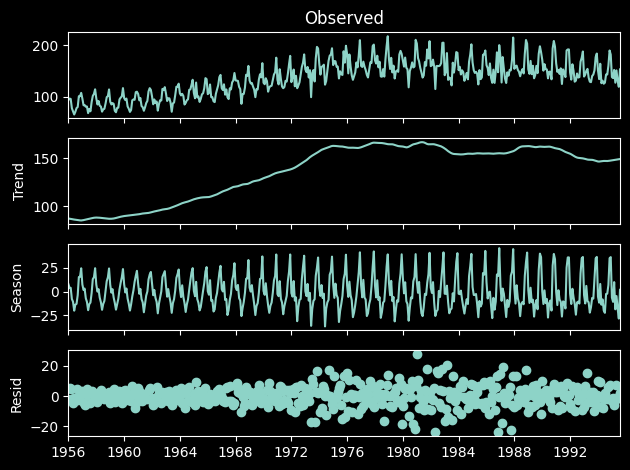

In [23]:
from statsmodels.tsa.seasonal import STL
stl = STL(df)
r = stl.fit()
r.plot()
plt.show()

In [24]:
df['Trend_1']=r.trend
df['Resid'] = r.resid

<Axes: xlabel='Month'>

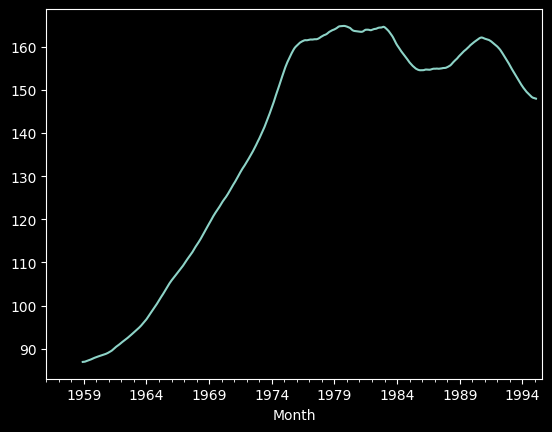

In [25]:
df['Trend']= res.trend
df['Seasonality']= res.seasonal
df['Residual']= res.resid
df['S_Trend'] = df['Trend'].rolling(30).mean()
df['S_Trend'].plot()

<Axes: xlabel='Month'>

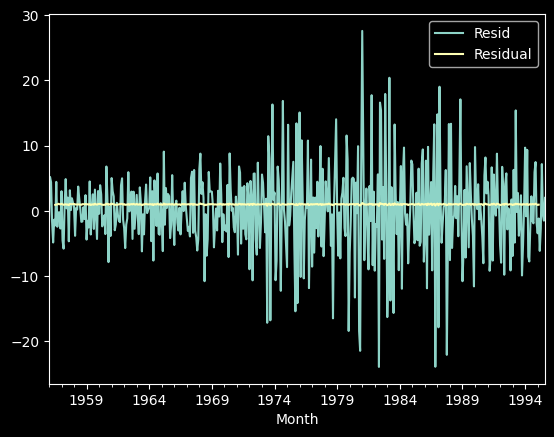

In [26]:
df[['Resid','Residual']].plot()

In [27]:
from statsmodels.tsa.stattools import adfuller
df['Trend_1'] = df['Trend']-df['Trend'].shift(1)
r = adfuller(df['Trend_1'].dropna())
r[1]<0.05

True

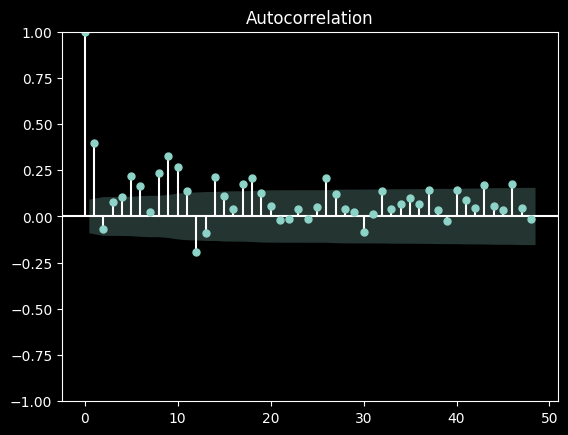

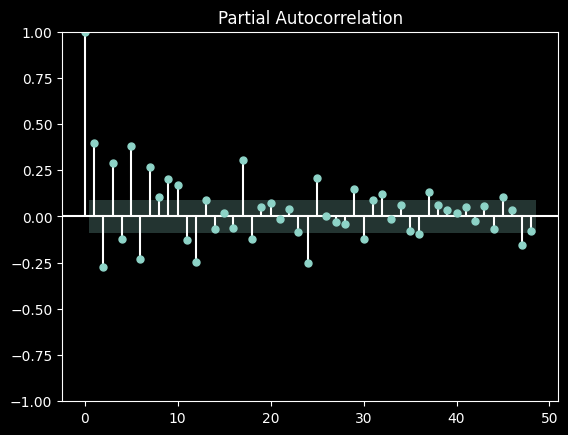

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
acf = plot_acf(df['Trend_1'].dropna(),lags=48)
pacf = plot_pacf(df['Trend_1'].dropna(),lags=48)

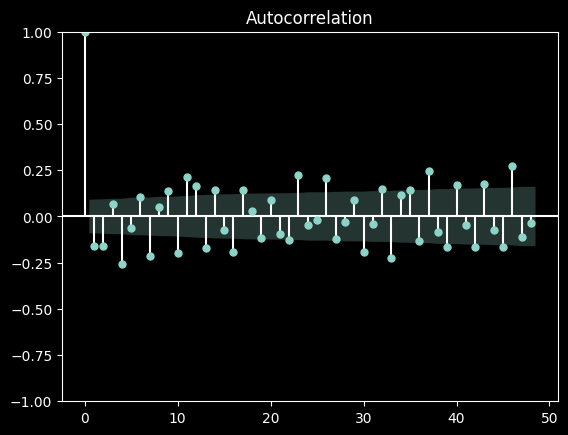

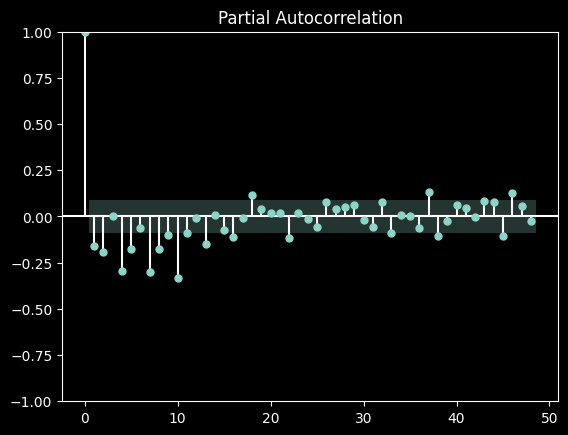

In [29]:
acf = plot_acf(df['Residual'].dropna(),lags=48)
pacf = plot_pacf(df['Residual'].dropna(),lags=48)

In [30]:
train = df.loc[:datetime(1984,1,1)].copy()
test = df.loc[datetime(1984,2,2):].copy()

In [31]:
from statsmodels.stats.diagnostic import acorr_ljungbox
result = acorr_ljungbox(df['Residual'].dropna(), lags=10, return_df=True)
print(result)

       lb_stat     lb_pvalue
1    12.303171  4.521893e-04
2    24.492706  4.802601e-06
3    26.601060  7.137306e-06
4    58.119341  7.203271e-12
5    59.804893  1.333688e-11
6    65.100103  4.115611e-12
7    87.125470  4.810728e-16
8    88.389144  9.869513e-16
9    97.626048  4.749080e-17
10  116.068620  3.169497e-20


In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train['Residual'].dropna(),order=(4,0,4),freq='MS').fit()
test['Pred_res'] = model.forecast(steps=139)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<Axes: xlabel='Month'>

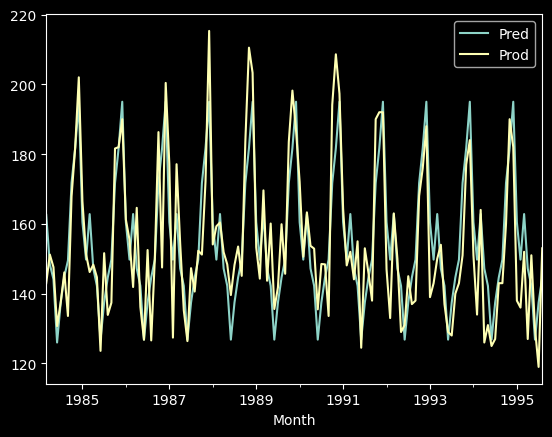

In [33]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train['Trend'],order=(3,1,1),freq='MS').fit()
test['Arima'] = model.forecast(steps=139)
test['Pred'] = test['Arima']*test['Seasonality']*test['Pred_res']
test[['Pred','Prod']].plot()

In [34]:
from sklearn.metrics import root_mean_squared_error as rmse
print("RMSE: ",rmse(test['Pred'],test['Prod']))

RMSE:  11.505080544624054
